# AI Based DoS Detection for SOC

## Project Overview

This project develops an AI-based network monitoring pipeline for detecting Denial-of-Service (DoS) attacks and assisting SOC analysts.

The system compares a supervised Random Forest model with an Isolation Forest anomaly detection model, evaluates their performance, and uses the selected model to generate risk scores, explainable evidence, MITRE ATT&CK mapping, SOC alerts, human review decisions, audit logs, and a retraining policy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
print("Current folder:", os.getcwd())
print("Files:")
print(os.listdir())

Current folder: C:\Users\nogah\Downloads\study\SOC_DoS_Project
Files:
['.ipynb_checkpoints', 'DoS_SOC_Detection.ipynb', 'soc_detection_log.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


## 1. Dataset – CICIDS2017

The CICIDS2017 dataset contains benign network traffic and several types of cyberattacks.  
For this project, the analysis focuses on benign traffic and DoS attacks.

In [4]:
df = pd.read_csv("Wednesday-workingHours.pcap_ISCX.csv")

In [5]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
print(df.shape)

(692703, 79)


In [7]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

## 2. Data Preprocessing

The dataset was preprocessed to focus on the binary classification task of Normal vs. DoS traffic.

The preprocessing process included:
- Filtering the dataset to retain benign traffic and DoS attack samples.
- Removing unrelated attack types.
- Converting the labels into a binary target:
  - 0 = Normal
  - 1 = DoS
- Handling missing values and infinite values to ensure the data is suitable for machine learning.

In [8]:
print(df[" Label"].value_counts())

 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


In [9]:
df_project = df[
    (df[" Label"] == "BENIGN") |
    (df[" Label"].str.contains("DoS"))
].copy()

In [10]:
print(df_project[" Label"].value_counts())

 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


In [11]:
df_project["target"] = df_project[" Label"].apply(
    lambda x: 0 if x == "BENIGN" else 1
)

In [12]:
print(df_project["target"].value_counts())
print()
print(df_project[[" Label", "target"]].head(20))

target
0    440031
1    252661
Name: count, dtype: int64

     Label  target
0   BENIGN       0
1   BENIGN       0
2   BENIGN       0
3   BENIGN       0
4   BENIGN       0
5   BENIGN       0
6   BENIGN       0
7   BENIGN       0
8   BENIGN       0
9   BENIGN       0
10  BENIGN       0
11  BENIGN       0
12  BENIGN       0
13  BENIGN       0
14  BENIGN       0
15  BENIGN       0
16  BENIGN       0
17  BENIGN       0
18  BENIGN       0
19  BENIGN       0


In [13]:
#סינון נתונים לנורמל ודוסים בלבד

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove extra spaces from Label values
df["Label"] = df["Label"].str.strip()

# Keep only BENIGN and DoS traffic
df_filtered = df[
    (df["Label"] == "BENIGN") |
    (df["Label"].str.startswith("DoS"))
].copy()

# Create binary target:
# 0 = Normal (BENIGN)
# 1 = DoS
df_filtered["target"] = np.where(
    df_filtered["Label"] == "BENIGN",
    0,
    1
)

print(df_filtered["Label"].value_counts())

print("\nTarget:")
print(df_filtered["target"].value_counts())

print("\nShape:")
print(df_filtered.shape)

Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64

Target:
target
0    440031
1    252661
Name: count, dtype: int64

Shape:
(692692, 80)


In [14]:
# Check for missing values
print("Missing values before cleaning:")
print(df_filtered.isnull().sum().sum())

# Replace infinity values with NaN
df_filtered.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove rows that contain NaN values
df_filtered.dropna(inplace=True)

# Check again
print("\nMissing values after cleaning:")
print(df_filtered.isnull().sum().sum())

print("\nShape after cleaning:")
print(df_filtered.shape)

Missing values before cleaning:
1008

Missing values after cleaning:
0

Shape after cleaning:
(691395, 80)


In [15]:
print(df_filtered.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [16]:
print("Number of columns:", len(df_filtered.columns))

Number of columns: 80


In [17]:
print(df_filtered.dtypes)

Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                              str
target                           int64
Length: 80, dtype: object


## 3. Feature Selection

A subset of network-flow features was selected for model training.

The selected features describe traffic volume, packet behavior, flow duration, packet rates, and TCP flag information. These features are used as the input variables for both the supervised and anomaly-detection models.

In [18]:
features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "SYN Flag Count",
    "ACK Flag Count"
]

In [19]:
X = df_filtered[features]
y = df_filtered["target"]

In [20]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nSelected features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (691395, 12)
y shape: (691395,)

Selected features:
['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Packet Length Mean', 'SYN Flag Count', 'ACK Flag Count']

Target distribution:
target
0    439683
1    251712
Name: count, dtype: int64


In [21]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 4. Train/Test Split

The dataset was divided into training and testing sets using an 80/20 split.

Stratified sampling was used to preserve the proportion of Normal and DoS samples in both sets.

The training set is used to train the models, while the test set is kept separate for performance evaluation on unseen data.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

X_train shape: (553116, 12)
X_test shape: (138279, 12)

Train distribution:
target
0    351746
1    201370
Name: count, dtype: int64

Test distribution:
target
0    87937
1    50342
Name: count, dtype: int64


## 5. Random Forest – Supervised Detection

Random Forest was used as the supervised learning model for binary classification of Normal vs. DoS traffic.

The model was trained using labeled training data and then evaluated on the unseen test set.

Its performance was measured using Accuracy, Precision, Recall, F1 Score, False Positive Rate, False Negative Rate, and a Confusion Matrix.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.9895935029903311
Precision: 0.9772793816244071
Recall: 0.9945373644273171
F1 Score: 0.9858328492808128

Confusion Matrix:
[[86773  1164]
 [  275 50067]]


In [25]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("False Positive Rate:", false_positive_rate)
print("False Negative Rate:", false_negative_rate)

False Positive Rate: 0.013236749036241856
False Negative Rate: 0.0054626355726828495


In [26]:
rf_accuracy = accuracy
rf_precision = precision
rf_recall = recall
rf_f1 = f1
rf_fpr = false_positive_rate
rf_fnr = false_negative_rate

print("Random Forest results saved.")

Random Forest results saved.


## 6. Isolation Forest – Anomaly Detection

Isolation Forest was used as an anomaly-detection model to identify traffic that differs from normal network behavior.

Unlike Random Forest, the model was trained only on Normal traffic and did not receive DoS labels during training.

The model was then evaluated on the same test set to determine how effectively DoS traffic could be detected as anomalous behavior.

In [27]:
X_train_normal = X_train[y_train == 0]

print("Normal training data shape:", X_train_normal.shape)

Normal training data shape: (351746, 12)


In [28]:
from sklearn.ensemble import IsolationForest

if_model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

if_model.fit(X_train_normal)

print("Isolation Forest training completed.")

Isolation Forest training completed.


In [29]:
# Predict on test data
if_predictions_raw = if_model.predict(X_test)

# Isolation Forest returns:
#  1 = Normal
# -1 = Anomaly

# Convert to our target format:
# 0 = Normal
# 1 = DoS / Anomaly
y_pred_if = np.where(if_predictions_raw == 1, 0, 1)

print("Isolation Forest predictions completed.")

Isolation Forest predictions completed.


In [30]:
if_accuracy = accuracy_score(y_test, y_pred_if)
if_precision = precision_score(y_test, y_pred_if)
if_recall = recall_score(y_test, y_pred_if)
if_f1 = f1_score(y_test, y_pred_if)

if_cm = confusion_matrix(y_test, y_pred_if)

tn_if, fp_if, fn_if, tp_if = if_cm.ravel()

if_fpr = fp_if / (fp_if + tn_if)
if_fnr = fn_if / (fn_if + tp_if)

print("Isolation Forest Results:")
print("Accuracy:", if_accuracy)
print("Precision:", if_precision)
print("Recall:", if_recall)
print("F1 Score:", if_f1)

print("\nFalse Positive Rate:", if_fpr)
print("False Negative Rate:", if_fnr)

print("\nConfusion Matrix:")
print(if_cm)

Isolation Forest Results:
Accuracy: 0.8066228422247774
Precision: 0.7854758333736513
Recall: 0.6449882801636804
F1 Score: 0.7083333333333334

False Positive Rate: 0.10084492306992505
False Negative Rate: 0.3550117198363196

Confusion Matrix:
[[79069  8868]
 [17872 32470]]


## 7. Model Evaluation & Comparison

The Random Forest and Isolation Forest models were compared using multiple performance metrics.

The evaluation includes:
- Accuracy
- Precision
- Recall
- F1 Score
- False Positive Rate
- False Negative Rate

The comparison helps determine which approach is more suitable for DoS detection in a SOC environment.

In [31]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_fpr,
        rf_fnr
    ],
    "Isolation Forest": [
        if_accuracy,
        if_precision,
        if_recall,
        if_f1,
        if_fpr,
        if_fnr
    ]
})

comparison

,Metric,Random Forest,Isolation Forest
0,Accuracy,0.989594,0.806623
1,Precision,0.977279,0.785476
2,Recall,0.994537,0.644988
3,F1 Score,0.985833,0.708333
4,False Positive Rate,0.013237,0.100845
5,False Negative Rate,0.005463,0.355012


## 8. SOC Risk Scoring & Policy Gate

The Random Forest model was selected as the primary detection model based on its stronger performance.

Instead of using only a binary Normal/DoS prediction, the model's DoS confidence score was used to assign a risk level.

The policy used in this prototype is:

- LOW: DoS Score < 0.50 → Log only
- MEDIUM: 0.50 ≤ DoS Score < 0.80 → Human review
- HIGH: DoS Score ≥ 0.80 → SOC alert + human review

No traffic is blocked automatically. High-risk events are escalated to a human analyst.

In [32]:
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("First 10 DoS probabilities:")
print(rf_probabilities[:10])

First 10 DoS probabilities:
[0.         0.         0.         0.         0.         0.96600192
 0.         0.         0.         1.        ]


In [33]:
soc_results = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Prediction": y_pred_rf,
    "DoS Score": rf_probabilities
})

soc_results["Risk Level"] = np.select(
    [
        soc_results["DoS Score"] >= 0.80,
        soc_results["DoS Score"] >= 0.50
    ],
    [
        "HIGH",
        "MEDIUM"
    ],
    default="LOW"
)

print(soc_results.head(20))

    Actual  Prediction  DoS Score Risk Level
0        0           0   0.000000        LOW
1        0           0   0.000000        LOW
2        0           0   0.000000        LOW
3        0           0   0.000000        LOW
4        0           0   0.000000        LOW
5        1           1   0.966002       HIGH
6        0           0   0.000000        LOW
7        0           0   0.000000        LOW
8        0           0   0.000000        LOW
9        1           1   1.000000       HIGH
10       1           1   1.000000       HIGH
11       0           0   0.000000        LOW
12       1           1   1.000000       HIGH
13       0           0   0.000000        LOW
14       0           0   0.000000        LOW
15       1           1   1.000000       HIGH
16       1           1   1.000000       HIGH
17       0           0   0.000000        LOW
18       0           0   0.000000        LOW
19       1           1   1.000000       HIGH


In [34]:
soc_results["SOC Action"] = np.select(
    [
        soc_results["Risk Level"] == "HIGH",
        soc_results["Risk Level"] == "MEDIUM"
    ],
    [
        "SOC ALERT + HUMAN REVIEW",
        "HUMAN REVIEW"
    ],
    default="LOG ONLY"
)

print(soc_results.head(20))

    Actual  Prediction  DoS Score Risk Level                SOC Action
0        0           0   0.000000        LOW                  LOG ONLY
1        0           0   0.000000        LOW                  LOG ONLY
2        0           0   0.000000        LOW                  LOG ONLY
3        0           0   0.000000        LOW                  LOG ONLY
4        0           0   0.000000        LOW                  LOG ONLY
5        1           1   0.966002       HIGH  SOC ALERT + HUMAN REVIEW
6        0           0   0.000000        LOW                  LOG ONLY
7        0           0   0.000000        LOW                  LOG ONLY
8        0           0   0.000000        LOW                  LOG ONLY
9        1           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW
10       1           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW
11       0           0   0.000000        LOW                  LOG ONLY
12       1           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW
13    

In [35]:
print("Risk Level Distribution:")
print(soc_results["Risk Level"].value_counts())

print("\nSOC Action Distribution:")
print(soc_results["SOC Action"].value_counts())

Risk Level Distribution:
Risk Level
LOW       87043
HIGH      50214
MEDIUM     1022
Name: count, dtype: int64

SOC Action Distribution:
SOC Action
LOG ONLY                    87043
SOC ALERT + HUMAN REVIEW    50214
HUMAN REVIEW                 1022
Name: count, dtype: int64


In [36]:
high_risk_alerts = soc_results[
    soc_results["Risk Level"] == "HIGH"
].copy()

print("Number of HIGH risk alerts:", len(high_risk_alerts))

print("\nExample SOC Alerts:")
print(
    high_risk_alerts[
        ["Actual", "Prediction", "DoS Score", "Risk Level", "SOC Action"]
    ].head(10)
)

Number of HIGH risk alerts: 50214

Example SOC Alerts:
    Actual  Prediction  DoS Score Risk Level                SOC Action
5        1           1   0.966002       HIGH  SOC ALERT + HUMAN REVIEW
9        1           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW
10       1           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW
12       1           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW
15       1           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW
16       1           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW
19       1           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW
21       1           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW
22       1           1   0.956823       HIGH  SOC ALERT + HUMAN REVIEW
23       1           1   0.908021       HIGH  SOC ALERT + HUMAN REVIEW


In [37]:
risk_vs_actual = pd.crosstab(
    soc_results["Risk Level"],
    soc_results["Actual"],
    rownames=["Risk Level"],
    colnames=["Actual"]
)

print(risk_vs_actual)

Actual          0      1
Risk Level              
HIGH          856  49358
LOW         86770    273
MEDIUM        311    711


## 9. Explainability & Evidence

To make the model's decisions more understandable to SOC analysts, two explainability approaches were used.

First, Random Forest feature importance was used to identify which network features were most influential across the model overall.

Second, a local perturbation-based analysis was used for individual alerts. Each feature was temporarily replaced with a typical value from Normal traffic, and the change in the DoS score was measured.

Features that caused the largest decrease in the DoS score were presented as local evidence for the alert.

This approach provides supporting evidence for the analyst without treating the explanation as a causal proof.

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                        Feature  Importance
9            Packet Length Mean    0.221673
8        Bwd Packet Length Mean    0.177784
4   Total Length of Bwd Packets    0.104920
6                Flow Packets/s    0.094498
2        Total Backward Packets    0.091866
5                  Flow Bytes/s    0.083415
0                 Flow Duration    0.072056
1             Total Fwd Packets    0.053443
3   Total Length of Fwd Packets    0.048392
7        Fwd Packet Length Mean    0.044795
11               ACK Flag Count    0.005220
10               SYN Flag Count    0.001939


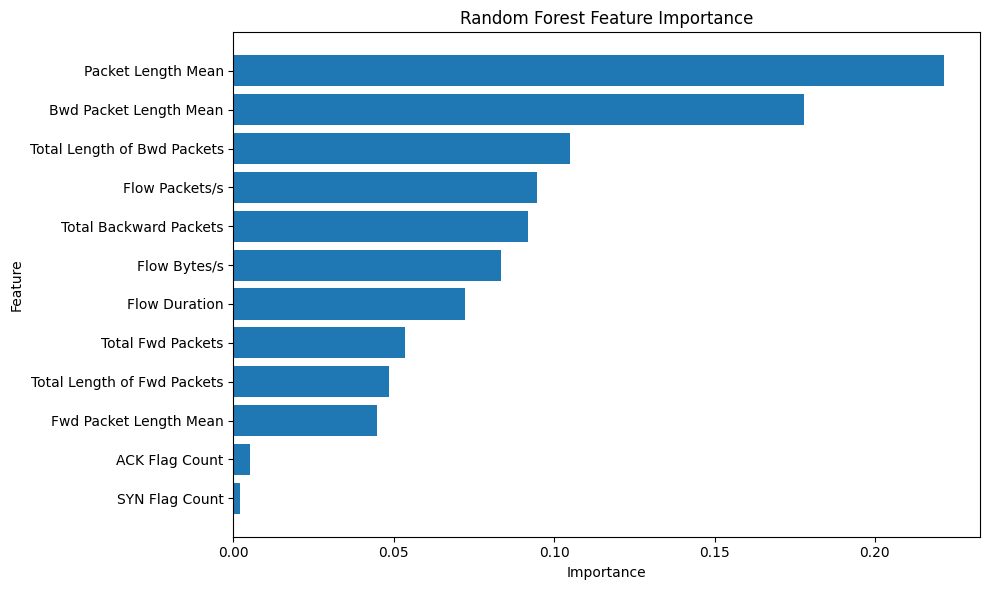

In [39]:
import matplotlib.pyplot as plt

feature_importance_sorted = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_sorted["Feature"],
    feature_importance_sorted["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [40]:
# Select the 5 most important features
top_features = feature_importance.head(5)["Feature"].tolist()

# Find the first HIGH-risk alert
high_alert_position = soc_results.index[
    soc_results["Risk Level"] == "HIGH"
][0]

# Get its network features
alert_values = X_test.iloc[high_alert_position][top_features]

# Calculate typical values in normal traffic
normal_medians = X_train_normal[top_features].median()

# Build evidence table
evidence = pd.DataFrame({
    "Feature": top_features,
    "Alert Value": [alert_values[f] for f in top_features],
    "Normal Median": [normal_medians[f] for f in top_features]
})

print("SOC ALERT")
print("Risk Level:", soc_results.iloc[high_alert_position]["Risk Level"])
print("DoS Score:", soc_results.iloc[high_alert_position]["DoS Score"])
print("SOC Action:", soc_results.iloc[high_alert_position]["SOC Action"])

print("\nEvidence:")
print(evidence)

SOC ALERT
Risk Level: HIGH
DoS Score: 0.9660019202069975
SOC Action: SOC ALERT + HUMAN REVIEW

Evidence:
                       Feature  Alert Value  Normal Median
0           Packet Length Mean          0.0      61.200000
1       Bwd Packet Length Mean          0.0      81.000000
2  Total Length of Bwd Packets          0.0     144.000000
3               Flow Packets/s    1000000.0     102.441883
4       Total Backward Packets          0.0       2.000000


In [41]:
normal_stats = pd.DataFrame({
    "Feature": top_features,
    "Normal 5th Percentile": [
        X_train_normal[f].quantile(0.05) for f in top_features
    ],
    "Normal Median": [
        X_train_normal[f].median() for f in top_features
    ],
    "Normal 95th Percentile": [
        X_train_normal[f].quantile(0.95) for f in top_features
    ],
    "Alert Value": [
        alert_values[f] for f in top_features
    ]
})

normal_stats["Evidence"] = normal_stats.apply(
    lambda row:
        "ABNORMALLY HIGH"
        if row["Alert Value"] > row["Normal 95th Percentile"]
        else (
            "ABNORMALLY LOW"
            if row["Alert Value"] < row["Normal 5th Percentile"]
            else "WITHIN NORMAL RANGE"
        ),
    axis=1
)

print(normal_stats)

                       Feature  Normal 5th Percentile  Normal Median  \
0           Packet Length Mean               0.000000      61.200000   
1       Bwd Packet Length Mean               0.000000      81.000000   
2  Total Length of Bwd Packets               0.000000     144.000000   
3               Flow Packets/s               0.286293     102.441883   
4       Total Backward Packets               0.000000       2.000000   

   Normal 95th Percentile  Alert Value             Evidence  
0              435.086302          0.0  WITHIN NORMAL RANGE  
1              701.600000          0.0  WITHIN NORMAL RANGE  
2             7149.000000          0.0  WITHIN NORMAL RANGE  
3           500000.000000    1000000.0      ABNORMALLY HIGH  
4               19.000000          0.0  WITHIN NORMAL RANGE  


In [42]:
abnormal_evidence = normal_stats[
    normal_stats["Evidence"] != "WITHIN NORMAL RANGE"
]

print("Abnormal Evidence:")
print(abnormal_evidence)

Abnormal Evidence:
          Feature  Normal 5th Percentile  Normal Median  \
3  Flow Packets/s               0.286293     102.441883   

   Normal 95th Percentile  Alert Value         Evidence  
3                500000.0    1000000.0  ABNORMALLY HIGH  


In [43]:
# Positions of all HIGH-risk alerts
high_positions = soc_results.index[
    soc_results["Risk Level"] == "HIGH"
]

# Feature values for HIGH-risk alerts
high_features = X_test.iloc[high_positions][top_features].copy()

# Count abnormal features for each alert
abnormal_counts = pd.Series(0, index=high_features.index)

for feature in top_features:
    low_threshold = X_train_normal[feature].quantile(0.05)
    high_threshold = X_train_normal[feature].quantile(0.95)

    abnormal_counts += (
        (high_features[feature] < low_threshold) |
        (high_features[feature] > high_threshold)
    ).astype(int)

print("HIGH alerts:", len(high_features))
print("HIGH alerts with at least one abnormal feature:",
      (abnormal_counts > 0).sum())

print("HIGH alerts with no abnormal feature:",
      (abnormal_counts == 0).sum())

print("\nAbnormal feature count distribution:")
print(abnormal_counts.value_counts().sort_index())

HIGH alerts: 50214
HIGH alerts with at least one abnormal feature: 41453
HIGH alerts with no abnormal feature: 8761

Abnormal feature count distribution:
0     8761
1     9414
2       53
3     4009
4    27977
Name: count, dtype: int64


In [44]:
all_features = X.columns.tolist()

high_features_all = X_test.iloc[high_positions][all_features].copy()

abnormal_counts_all = pd.Series(0, index=high_features_all.index)

for feature in all_features:
    low_threshold = X_train_normal[feature].quantile(0.05)
    high_threshold = X_train_normal[feature].quantile(0.95)

    abnormal_counts_all += (
        (high_features_all[feature] < low_threshold) |
        (high_features_all[feature] > high_threshold)
    ).astype(int)

print("HIGH alerts:", len(high_features_all))

print(
    "HIGH alerts with at least one abnormal feature:",
    (abnormal_counts_all > 0).sum()
)

print(
    "HIGH alerts with no abnormal feature:",
    (abnormal_counts_all == 0).sum()
)

print("\nAbnormal feature count distribution:")
print(abnormal_counts_all.value_counts().sort_index())

HIGH alerts: 50214
HIGH alerts with at least one abnormal feature: 41543
HIGH alerts with no abnormal feature: 8671

Abnormal feature count distribution:
0     8671
1     2238
2     6982
3     3888
4    27685
5      741
6        9
Name: count, dtype: int64


In [45]:
# Choose one HIGH-risk alert
alert_position = soc_results.index[
    soc_results["Risk Level"] == "HIGH"
][0]

alert_sample = X_test.iloc[[alert_position]].copy()

# Original DoS score
original_score = rf_model.predict_proba(alert_sample)[0, 1]

local_evidence = []

for feature in X.columns:
    modified_sample = alert_sample.copy()

    # Replace this feature with the normal median
    modified_sample[feature] = X_train_normal[feature].median()

    new_score = rf_model.predict_proba(modified_sample)[0, 1]

    impact = original_score - new_score

    local_evidence.append({
        "Feature": feature,
        "Original DoS Score": original_score,
        "Score After Normalization": new_score,
        "Impact": impact
    })

local_evidence = pd.DataFrame(local_evidence)

local_evidence = local_evidence.sort_values(
    by="Impact",
    ascending=False
)

print(local_evidence)

                        Feature  Original DoS Score  \
11               ACK Flag Count            0.966002   
7        Fwd Packet Length Mean            0.966002   
9            Packet Length Mean            0.966002   
0                 Flow Duration            0.966002   
2        Total Backward Packets            0.966002   
6                Flow Packets/s            0.966002   
5                  Flow Bytes/s            0.966002   
4   Total Length of Bwd Packets            0.966002   
3   Total Length of Fwd Packets            0.966002   
8        Bwd Packet Length Mean            0.966002   
1             Total Fwd Packets            0.966002   
10               SYN Flag Count            0.966002   

    Score After Normalization        Impact  
11                   0.000000  9.660019e-01  
7                    0.586344  3.796583e-01  
9                    0.594505  3.714968e-01  
0                    0.611937  3.540646e-01  
2                    0.640145  3.258564e-01  
6       

In [46]:
top_local_evidence = local_evidence[
    local_evidence["Impact"] > 0
].head(3).copy()

top_local_evidence["Alert Value"] = [
    alert_sample.iloc[0][feature]
    for feature in top_local_evidence["Feature"]
]

top_local_evidence["Normal Median"] = [
    X_train_normal[feature].median()
    for feature in top_local_evidence["Feature"]
]

top_local_evidence = top_local_evidence[
    [
        "Feature",
        "Alert Value",
        "Normal Median",
        "Score After Normalization",
        "Impact"
    ]
]

print("FINAL SOC ALERT")
print("-------------------------")
print("Risk Level: HIGH")
print(f"DoS Score: {original_score:.3f}")
print("Action: SOC ALERT + HUMAN REVIEW")

print("\nTop Evidence:")
print(top_local_evidence)

FINAL SOC ALERT
-------------------------
Risk Level: HIGH
DoS Score: 0.966
Action: SOC ALERT + HUMAN REVIEW

Top Evidence:
                   Feature  Alert Value  Normal Median  \
11          ACK Flag Count          1.0            0.0   
7   Fwd Packet Length Mean          0.0           38.0   
9       Packet Length Mean          0.0           61.2   

    Score After Normalization    Impact  
11                   0.000000  0.966002  
7                    0.586344  0.379658  
9                    0.594505  0.371497  


## 10. Human-in-the-Loop & Audit Logging

High- and medium-risk events are escalated for human review rather than being acted on automatically.

The analyst can confirm the event as a DoS attack or mark it as a false positive.

All analyzed events are stored in an audit log together with:
- Event ID
- Model prediction
- DoS score
- Risk level
- SOC action
- Analyst decision
- Ground-truth label for experimental evaluation

This supports traceability, auditability, and future learning from analyst feedback.

In [47]:
soc_log = soc_results.copy()

soc_log["Event ID"] = range(1, len(soc_log) + 1)

soc_log = soc_log[
    [
        "Event ID",
        "Prediction",
        "DoS Score",
        "Risk Level",
        "SOC Action",
        "Actual"
    ]
]

print(soc_log.head(10))

   Event ID  Prediction  DoS Score Risk Level                SOC Action  \
0         1           0   0.000000        LOW                  LOG ONLY   
1         2           0   0.000000        LOW                  LOG ONLY   
2         3           0   0.000000        LOW                  LOG ONLY   
3         4           0   0.000000        LOW                  LOG ONLY   
4         5           0   0.000000        LOW                  LOG ONLY   
5         6           1   0.966002       HIGH  SOC ALERT + HUMAN REVIEW   
6         7           0   0.000000        LOW                  LOG ONLY   
7         8           0   0.000000        LOW                  LOG ONLY   
8         9           0   0.000000        LOW                  LOG ONLY   
9        10           1   1.000000       HIGH  SOC ALERT + HUMAN REVIEW   

   Actual  
0       0  
1       0  
2       0  
3       0  
4       0  
5       1  
6       0  
7       0  
8       0  
9       1  


In [48]:
soc_log.to_csv(
    "soc_detection_log.csv",
    index=False
)

print("SOC log saved successfully.")
print("Total logged events:", len(soc_log))

SOC log saved successfully.
Total logged events: 138279


In [49]:
soc_log["Analyst Decision"] = np.where(
    soc_log["SOC Action"] == "LOG ONLY",
    "NOT REQUIRED",
    "PENDING REVIEW"
)

print(soc_log["Analyst Decision"].value_counts())

Analyst Decision
NOT REQUIRED      87043
PENDING REVIEW    51236
Name: count, dtype: int64


In [50]:
def analyst_review(event_id, decision):
    valid_decisions = [
        "CONFIRMED DOS",
        "FALSE POSITIVE"
    ]

    if decision not in valid_decisions:
        print("Invalid decision.")
        return

    mask = soc_log["Event ID"] == event_id

    if not mask.any():
        print("Event ID not found.")
        return

    soc_log.loc[mask, "Analyst Decision"] = decision

    print("Analyst decision saved.")
    print(
        soc_log.loc[
            mask,
            [
                "Event ID",
                "Prediction",
                "DoS Score",
                "Risk Level",
                "SOC Action",
                "Analyst Decision"
            ]
        ]
    )

In [51]:
analyst_review(6, "CONFIRMED DOS")

Analyst decision saved.
   Event ID  Prediction  DoS Score Risk Level                SOC Action  \
5         6           1   0.966002       HIGH  SOC ALERT + HUMAN REVIEW   

  Analyst Decision  
5    CONFIRMED DOS  


In [52]:
soc_log.to_csv(
    "soc_detection_log.csv",
    index=False
)

print("Updated SOC log saved successfully.")

Updated SOC log saved successfully.


## 11. MITRE ATT&CK Mapping

Detected DoS events are mapped to the MITRE ATT&CK framework to provide a standardized description of the identified threat.

For this project, suspected network DoS activity is mapped to:

- Tactic: Impact
- Technique ID: T1498
- Technique: Network Denial of Service

The MITRE mapping does not perform the detection itself. The Random Forest model performs the detection, while MITRE ATT&CK is used to describe and contextualize the detected threat for the SOC analyst.

In [53]:
soc_log["MITRE Tactic"] = np.where(
    soc_log["Prediction"] == 1,
    "Impact",
    "N/A"
)

soc_log["MITRE Technique ID"] = np.where(
    soc_log["Prediction"] == 1,
    "T1498",
    "N/A"
)

soc_log["MITRE Technique"] = np.where(
    soc_log["Prediction"] == 1,
    "Network Denial of Service",
    "N/A"
)

print(
    soc_log[
        [
            "Event ID",
            "Prediction",
            "DoS Score",
            "Risk Level",
            "MITRE Tactic",
            "MITRE Technique ID",
            "MITRE Technique",
            "Analyst Decision"
        ]
    ].head(10)
)

   Event ID  Prediction  DoS Score Risk Level MITRE Tactic MITRE Technique ID  \
0         1           0   0.000000        LOW          N/A                N/A   
1         2           0   0.000000        LOW          N/A                N/A   
2         3           0   0.000000        LOW          N/A                N/A   
3         4           0   0.000000        LOW          N/A                N/A   
4         5           0   0.000000        LOW          N/A                N/A   
5         6           1   0.966002       HIGH       Impact              T1498   
6         7           0   0.000000        LOW          N/A                N/A   
7         8           0   0.000000        LOW          N/A                N/A   
8         9           0   0.000000        LOW          N/A                N/A   
9        10           1   1.000000       HIGH       Impact              T1498   

             MITRE Technique Analyst Decision  
0                        N/A     NOT REQUIRED  
1           

In [54]:
soc_log.to_csv(
    "soc_detection_log.csv",
    index=False
)

print("SOC log with MITRE mapping saved successfully.")

SOC log with MITRE mapping saved successfully.


## 12. Final SOC Alert Demo

The final SOC alert combines the main components of the detection pipeline into a single analyst-facing output.

For a selected event, the alert displays:

- Event ID
- Model prediction
- DoS confidence score
- Risk level
- MITRE ATT&CK mapping
- SOC action
- Analyst decision
- Top local evidence

This demonstrates how the machine-learning output is converted into an interpretable and actionable SOC alert.

In [55]:
def show_soc_alert(event_id):
    row = soc_log[soc_log["Event ID"] == event_id]

    if row.empty:
        print("Event ID not found.")
        return

    row = row.iloc[0]

    print("========== SOC ALERT ==========")
    print("Event ID:", event_id)
    print("Prediction:", "Possible DoS" if row["Prediction"] == 1 else "Normal")
    print(f"DoS Score: {row['DoS Score']:.3f}")
    print("Risk Level:", row["Risk Level"])

    print("\nMITRE ATT&CK:")
    print("Tactic:", row["MITRE Tactic"])
    print("Technique ID:", row["MITRE Technique ID"])
    print("Technique:", row["MITRE Technique"])

    print("\nSOC Action:")
    print(row["SOC Action"])

    print("\nAnalyst Decision:")
    print(row["Analyst Decision"])

    # Local evidence only for suspected DoS events
    if row["Prediction"] == 1:
        position = event_id - 1
        sample = X_test.iloc[[position]].copy()

        original_score = rf_model.predict_proba(sample)[0, 1]

        evidence_list = []

        for feature in X.columns:
            modified_sample = sample.copy()
            modified_sample[feature] = X_train_normal[feature].median()

            new_score = rf_model.predict_proba(modified_sample)[0, 1]
            impact = original_score - new_score

            if impact > 0:
                evidence_list.append({
                    "Feature": feature,
                    "Impact": impact
                })

        evidence_df = pd.DataFrame(evidence_list)

        if not evidence_df.empty:
            evidence_df = evidence_df.sort_values(
                by="Impact",
                ascending=False
            ).head(3)

            print("\nTop Local Evidence:")
            print(evidence_df)

    print("===============================")

In [56]:
show_soc_alert(6)

========== SOC ALERT ==========
Event ID: 6
Prediction: Possible DoS
DoS Score: 0.966
Risk Level: HIGH

MITRE ATT&CK:
Tactic: Impact
Technique ID: T1498
Technique: Network Denial of Service

SOC Action:
SOC ALERT + HUMAN REVIEW

Analyst Decision:
CONFIRMED DOS

Top Local Evidence:
                   Feature    Impact
11          ACK Flag Count  0.966002
7   Fwd Packet Length Mean  0.379658
9       Packet Length Mean  0.371497


## 13. Monitoring & Retraining Policy

A simple model-monitoring policy was defined to identify when the deployed detection model may require retraining.

The current policy monitors two security-relevant performance metrics:

- Recall must remain at or above 95%.
- False Positive Rate must remain at or below 5%.

If either threshold is violated on newly evaluated traffic, the system triggers a retraining recommendation.

In this prototype, the policy is demonstrated using the test-set results. A real production system would evaluate these metrics periodically on newly labeled traffic to detect performance degradation or possible model drift.

In [57]:
# Drift / Retraining policy thresholds
MIN_RECALL = 0.95
MAX_FALSE_POSITIVE_RATE = 0.05

print("Model Monitoring Status")
print("-----------------------")
print(f"Current Recall: {rf_recall:.4f}")
print(f"Current False Positive Rate: {rf_fpr:.4f}")

if rf_recall < MIN_RECALL or rf_fpr > MAX_FALSE_POSITIVE_RATE:
    print("\nStatus: RETRAINING REQUIRED")
    print("Reason: Model performance crossed the monitoring threshold.")
else:
    print("\nStatus: MODEL PERFORMANCE STABLE")
    print("No retraining is currently required.")

Model Monitoring Status
-----------------------
Current Recall: 0.9945
Current False Positive Rate: 0.0132

Status: MODEL PERFORMANCE STABLE
No retraining is currently required.


## 14. Final Results & Conclusion

The final evaluation compares the Random Forest and Isolation Forest models and summarizes the overall SOC detection pipeline.

Random Forest achieved substantially stronger performance for the selected DoS detection task, with higher Accuracy, Precision, Recall, and F1 Score, while also producing lower False Positive and False Negative rates.

For this reason, Random Forest was selected as the primary detection model used in the SOC pipeline.

The final system combines:
- Machine-learning-based DoS detection
- Risk scoring and policy-based escalation
- Explainable evidence
- MITRE ATT&CK mapping
- Human-in-the-loop review
- Audit logging
- Model monitoring and retraining recommendations

The results demonstrate that supervised learning is highly effective for detecting known DoS patterns in the selected CICIDS2017 data, while anomaly detection may still be useful for identifying previously unseen or unusual network behavior.

In [58]:
final_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Isolation Forest"
    ],
    "Accuracy": [
        rf_accuracy,
        if_accuracy
    ],
    "Precision": [
        rf_precision,
        if_precision
    ],
    "Recall": [
        rf_recall,
        if_recall
    ],
    "F1 Score": [
        rf_f1,
        if_f1
    ],
    "False Positive Rate": [
        rf_fpr,
        if_fpr
    ],
    "False Negative Rate": [
        rf_fnr,
        if_fnr
    ]
})

final_results = final_results.round(4)

print("Final Model Comparison:")
print(final_results)

Final Model Comparison:
              Model  Accuracy  Precision  Recall  F1 Score  \
0     Random Forest    0.9896     0.9773  0.9945    0.9858   
1  Isolation Forest    0.8066     0.7855  0.6450    0.7083   

   False Positive Rate  False Negative Rate  
0               0.0132               0.0055  
1               0.1008               0.3550  


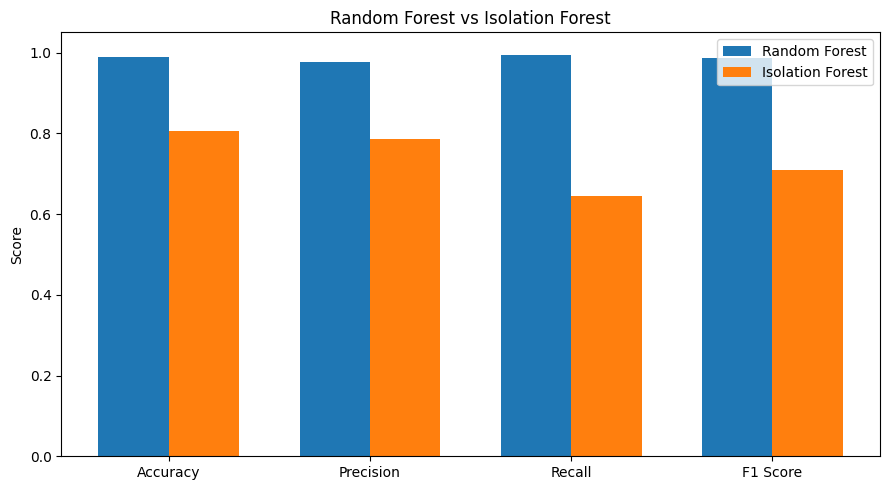

In [59]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

rf_values = [
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1
]

if_values = [
    if_accuracy,
    if_precision,
    if_recall,
    if_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, rf_values, width, label="Random Forest")
plt.bar(x + width/2, if_values, width, label="Isolation Forest")

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Random Forest vs Isolation Forest")
plt.legend()

plt.tight_layout()
plt.show()

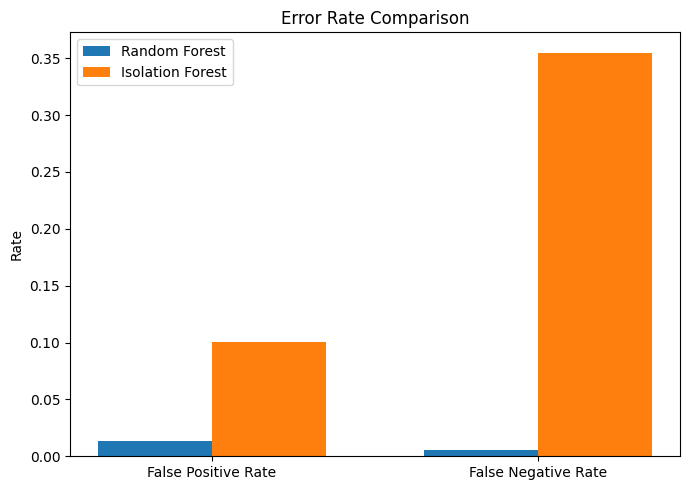

In [60]:
error_metrics = [
    "False Positive Rate",
    "False Negative Rate"
]

rf_errors = [
    rf_fpr,
    rf_fnr
]

if_errors = [
    if_fpr,
    if_fnr
]

x = np.arange(len(error_metrics))
width = 0.35

plt.figure(figsize=(7, 5))

plt.bar(x - width/2, rf_errors, width, label="Random Forest")
plt.bar(x + width/2, if_errors, width, label="Isolation Forest")

plt.xticks(x, error_metrics)
plt.ylabel("Rate")
plt.title("Error Rate Comparison")
plt.legend()

plt.tight_layout()
plt.show()

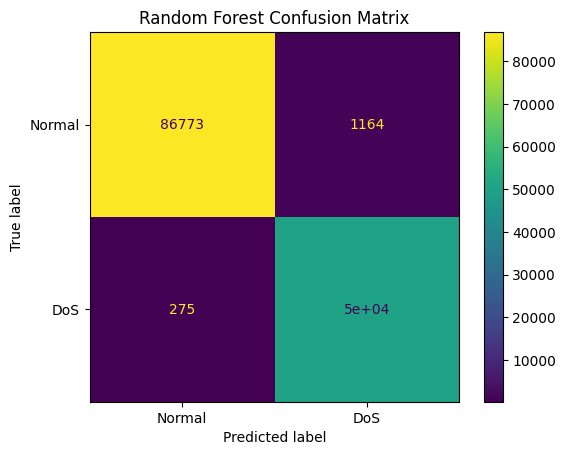

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normal", "DoS"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()